In [1]:
import pandas as pd
import numpy as np
import minsearch
from dotenv import load_dotenv
import os 
from openai import OpenAI
from tqdm.auto import tqdm
import json
import matplotlib.pyplot as plt
import seaborn as sns
from groq import Groq

load_dotenv()
client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))
# client_groq = Groq(api_key=os.environ.get("GROQ_API_KEY"))

## Data Ingestion

In [2]:
data = pd.read_csv('data/Mental_Health_FAQ.csv', index_col=False)
data = data.rename(columns={'Question_ID': 'question_id', 'Questions': 'questions', 'Answers': 'answers'})
data.head()

,question_id,questions,answers
0,1590140,What does it mean to have a mental illness?,Mental illnesses are health conditions that di...
1,2110618,Who does mental illness affect?,It is estimated that mental illness affects 1 ...
2,6361820,What causes mental illness?,It is estimated that mental illness affects 1 ...
3,9434130,What are some of the warning signs of mental i...,Symptoms of mental health disorders vary depen...
4,7657263,Can people with mental illness recover?,"When healing from mental illness, early identi..."


In [3]:
data.head(10)

,question_id,questions,answers
0,1590140,What does it mean to have a mental illness?,Mental illnesses are health conditions that di...
1,2110618,Who does mental illness affect?,It is estimated that mental illness affects 1 ...
2,6361820,What causes mental illness?,It is estimated that mental illness affects 1 ...
3,9434130,What are some of the warning signs of mental i...,Symptoms of mental health disorders vary depen...
4,7657263,Can people with mental illness recover?,"When healing from mental illness, early identi..."
5,1619387,What should I do if I know someone who appears...,Although this website cannot substitute for pr...
6,1030153,How can I find a mental health professional fo...,Feeling comfortable with the professional you ...
7,8022026,What treatment options are available?,Just as there are different types of medicatio...
8,1155199,"If I become involved in treatment, what do I n...",Since beginning treatment is a big step for in...
9,7760466,What is the difference between mental health p...,There are many types of mental health professi...


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   question_id  98 non-null     int64 
 1   questions    98 non-null     object
 2   answers      98 non-null     object
dtypes: int64(1), object(2)
memory usage: 2.4+ KB


In [5]:
documents = data.to_dict(orient='records')

In [6]:
documents[10]

{'question_id': 2553795,
 'questions': 'How can I find a mental health professional right for my child or myself?',
 'answers': 'Feeling comfortable with the professional you or your child is working with is critical to the success of your treatment. Finding the professional who best fits your needs may require some research.'}

## Index Document with Minsearch

In [7]:
index = minsearch.Index(text_fields=['questions', 'answers'], keyword_fields=[])

In [8]:
index.fit(documents)

In [9]:
query='What is the difference between a psychologist and a psychiatrist?'

In [10]:
index.search(query)

[{'question_id': 6851366,
  'questions': "What's the difference between a psychiatrist and a registered psychologist?",
  'answers': 'A psychiatrist is a medical doctor with extra training in mental health who can choose to prescribe medications. Some use psychotherapy (‘talk therapies’) approaches like cognitive-behavioural therapy to treat mental health problems. Many psychiatrists work at hospitals, clinics, or health centres, and some have a private office. As they are specialist doctors, you will almost always need another doctor’s referral to see a psychiatrist, and fees are covered by MSP. If you have a valid BC Services or CareCard, you do not need to pay to see a psychiatrist. \n A registered psychologist focuses on different talk therapy or counselling approaches to treatments, but they don’t prescribe medication. They have graduate degrees in psychology. There are two different ways to access registered psychologists: the public system and the private system. Registered psyc

## Evaluating Retrieval

In [11]:
questions = pd.read_csv('../mentalhealthqa/data/ground_truth_data.csv')

In [12]:
questions.head(10)

,id,question
0,1590140,How do mental conditions affect daily life and...
1,1590140,What is the range of severity for mental illne...
2,1590140,What serious disorders require hospital care?
3,1590140,How are mental illnesses similar to physical h...
4,1590140,What treatments are effective for managing men...
5,2110618,How many adults in America are affected by men...
6,2110618,Can you explain how mental illness impacts dif...
7,2110618,What age groups are particularly vulnerable to...
8,2110618,Why is it challenging to identify mental healt...
9,2110618,What signs should parents look for to detect m...


In [13]:
ground_truth = questions.to_dict(orient='records')
ground_truth[10]

{'id': 6361820,
 'question': 'How common is mental illness among adults in America?'}

In [14]:
def hit_rate(relevance_total):
    count=0
    for i in relevance_total:
        if True in i:
            count= count + 1
    return count / len(relevance_total)

In [15]:
def mrr(relevance_total):
    total_score = 0.0
    for i in relevance_total:
        for rank in range(len(i)):
            if i[rank]== True:
                total_score= total_score + 1 / (rank + 1)
    return total_score / len(relevance_total)

In [16]:
def minsearch_search(query):
    boost = {}

    results = index.search(
        query=query,
        filter_dict={},
        boost_dict=boost,
        num_results=5
    )

    return results

In [17]:
def precision(rel_list):
    
    true_retrieved= sum(rel_list)
    total_retrieved= len(rel_list)
    if total_retrieved==0:
        return 0.0
    return true_retrieved / total_retrieved

In [18]:
def recall(rel_list, total_retrieved):
    # ratio of relevant documents that were succesfully retrieved
    true_list= sum(rel_list)
    if total_retrieved == 0:
        return 0.0
    return true_list / total_retrieved

In [19]:
def evaluate(ground_truth, search_func):
    relevance_total = []
    precision_scores=[]
    recall_scores=[]
    for i in tqdm(ground_truth):
        document_id = i['id']
        results = search_func(i)
        # check if the correct document is in the results (check by matching id)
        relevance = [r['question_id'] == document_id for r in results]
        relevance_total.append(relevance)

        # precision: the portion of retrieved documenst that are relevant
        precision_score = precision(relevance)
        precision_scores.append(precision_score)

        # recall: here recall is either 1 or 0, since it is only one relevant doc per query
        recall_score= recall(relevance, 1)
        recall_scores.append(recall_score)
    return {'hit_rate': hit_rate(relevance_total), 'mrr': mrr(relevance_total), 'precision': sum(precision_scores)/ len(precision_scores), 'recall': sum(recall_scores)/len(recall_scores)}

In [20]:
evaluate(ground_truth, lambda q: minsearch_search(q['question']))

  0%|          | 0/490 [00:00<?, ?it/s]

{'hit_rate': 0.6775510204081633,
 'mrr': 0.49346938775510196,
 'precision': 0.13551020408163347,
 'recall': 0.6775510204081633}

Evaluate shows we have a relatively high recall and low precision, this suggests the system is finding most of the relavant documents but we still retrieving a lot of irrelevant ones, i have to improve both the precision by tuning the seacrh algorithm, adjusting boostinf and filtering irrelevant ones.

In [21]:
df_validation = ground_truth[:100]
df_test= ground_truth[100:]

In [22]:
import random
def simple_optimize(param_ranges, objective_function, n_iterations=10):
    best_params = None
    best_score = float('-inf')  # Assuming we're minimizing. Use float('-inf') if maximizing.

    for _ in range(n_iterations):
        # Generate random parameters
        current_params = {}
        for param, (min_val, max_val) in param_ranges.items():
            if isinstance(min_val, int) and isinstance(max_val, int):
                current_params[param] = random.randint(min_val, max_val)
            else:
                current_params[param] = random.uniform(min_val, max_val)
        
        # Evaluate the objective function
        current_score = objective_function(current_params)
        
        # Update best if current is better
        if current_score > best_score:  # Change to > if maximizing
            best_score = current_score
            best_params = current_params
    
    return best_params, best_score

In [23]:
def minsearch_search(query, boost=None, num_results=10):
    if boost is None:
        boost = {}

    results = index.search(
        query=query,
        filter_dict={},
        boost_dict=boost,
        num_results=num_results
    )

    return results

In [24]:
gt_val= ground_truth[:100]
gt_val[0]

{'id': 1590140,
 'question': 'How do mental conditions affect daily life and relationships?'}

In [25]:

parameter_ranges= {
    'Questions': (0.0, 3.0),
    'Answers': (0.0, 3.0),
    'num_results': (1, 10),
}

def objective(params):
    params = params.copy()
    num_results = params.pop('num_results')   # it's not a boost weight
    boost_params = params 

    def search_function(q):
        return minsearch_search(q['question'], boost=boost_params, num_results=num_results)

    results = evaluate(gt_val, search_function)
    return results['mrr']




In [26]:
random.seed(42) 
best_params, best_score = simple_optimize(parameter_ranges, objective, n_iterations=20)
print(best_params, best_score)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

{'Questions': 0.23640059423537452, 'Answers': 0.8795348442212787, 'num_results': 10} 0.39111111111111113


In [27]:
def minsearch_improved(query):
    boost= {
        'Questions': 0.2364, 
        'Answers': 0.8795,
    }
    results= index.search(
        query=query, 
        filter_dict={},
        boost_dict=boost, 
        num_results=10
    )
    return results

evaluate(ground_truth, lambda m: minsearch_improved(m['question']))

  0%|          | 0/490 [00:00<?, ?it/s]

{'hit_rate': 0.7714285714285715,
 'mrr': 0.5058001295756397,
 'precision': 0.0771428571428577,
 'recall': 0.7714285714285715}

## RAG LOGIC

In [28]:
def search(query):
    boost= {}
    results = index.search(query=query, filter_dict={}, boost_dict=boost, num_results=5)
    return results

In [29]:
template="""
You are an expert mental health assistant specialized in providing detailed and accurate answers based on the given context.
Answer the QUESTION based on the CONTEXT from our mental health database.
Use only the facts from the CONTEXT when answering the QUESTION.

Here is the context:

Context: {context}

Please answer the following question based on the provided context:

Question: {question}

Provide a detailed and informative response. Ensure that your answer is clear, concise, and directly addresses the question while being relevant to the context provided.

Your response should be in plain text and should not include any code blocks or extra formatting.

Answer:
""".strip()

In [30]:
def build_prompt(query, search_results):
    context= ""
    for doc in search_results:
        context = context.format(**doc) + '\n\n'
    prompt = template.format(question=query, context=context).strip()
    return prompt

In [31]:
def llm(prompt, model):
    response= client.chat.completions.create(model=model, messages=[{"role": "user", "content": prompt}])
    return response.choices[0].message.content

In [32]:
def rag(query, model='gpt-4o-mini'):
    search_results = search(query)
    prompt = build_prompt(query, search_results)
    #print(prompt)
    answer = llm(prompt, model=model)
    return answer


In [33]:
question = 'How common is mental illness among adults in America?'
answer = rag(question)
print(answer)

The context provided does not contain specific information regarding the prevalence of mental illness among adults in America. Therefore, I cannot provide a detailed answer based on the given context. For accurate information on this topic, I recommend referring to reputable sources such as the National Institute of Mental Health or the Centers for Disease Control and Prevention.


## RAG Evaluation

In [34]:
template_2=  """
You are an expert evaluator for a RAG system.
Your task is to analyze the relevance of the generated answer to the given question.
Based on the relevance of the generated answer, you will classify it
as "NON_RELEVANT", "PARTLY_RELEVANT", or "RELEVANT".

Here is the data for evaluation:

Question: {question}
Generated Answer: {answer_llm}

Please analyze the content and context of the generated answer in relation to the question
and provide your evaluation in parsable JSON without using code blocks:

{{
  "Relevance": "NON_RELEVANT" | "PARTLY_RELEVANT" | "RELEVANT",
  "Explanation": "[Provide a summary for your evaluation]"
}}
""".strip()

In [35]:
len(ground_truth)

490

In [36]:
ground_truth[10]

{'id': 6361820,
 'question': 'How common is mental illness among adults in America?'}

In [37]:
record = ground_truth[10]
q = record['question']
# print(q)
answer_llm = rag(q)

In [38]:
prompt_2= template_2.format(question=q,answer_llm=answer_llm)
print(prompt_2)

You are an expert evaluator for a RAG system.
Your task is to analyze the relevance of the generated answer to the given question.
Based on the relevance of the generated answer, you will classify it
as "NON_RELEVANT", "PARTLY_RELEVANT", or "RELEVANT".

Here is the data for evaluation:

Question: How common is mental illness among adults in America?
Generated Answer: Mental illness is quite common among adults in America. According to various mental health statistics, approximately one in five adults in the United States experience mental illness each year. This translates to tens of millions of individuals affected, indicating that mental health issues are a significant public health concern. The prevalence of mental illnesses can vary widely, encompassing a range of disorders such as depression, anxiety, and more severe conditions like schizophrenia and bipolar disorder. It is essential for individuals to seek help and for societal efforts to focus on destigmatization and increasing 

In [39]:
record = ground_truth[0]
q = record['question']
# print(q)
answer_llm = rag(q)

In [40]:
prompt_2= template_2.format(question=q,answer_llm=answer_llm)
print(prompt_2)

You are an expert evaluator for a RAG system.
Your task is to analyze the relevance of the generated answer to the given question.
Based on the relevance of the generated answer, you will classify it
as "NON_RELEVANT", "PARTLY_RELEVANT", or "RELEVANT".

Here is the data for evaluation:

Question: How do mental conditions affect daily life and relationships?
Generated Answer: Mental conditions can significantly impact daily life and relationships in various ways. Individuals may experience challenges in managing daily tasks, maintaining a consistent routine, and coping with stressors due to symptoms such as fatigue, anxiety, or lack of motivation. This can lead to difficulties in work or academic performance, as well as trouble with time management and organization.

In relationships, mental health conditions can create barriers to effective communication and emotional connections. Individuals may find it hard to express their feelings or may withdraw from social interactions, leading t

In [41]:
evaluations=[]
for record in tqdm(ground_truth):
    doc_id=record['id']
    if id in evaluations:
        continue
    question=record['question']
    llm_answer=rag(question)
    prompt=template_2.format(question=question, answer_llm=llm_answer)
    evaluation=llm(prompt, model='gpt-4o-mini')
    eval= json.loads(evaluation)
    evaluations.append((record, llm_answer, eval))

  0%|          | 0/490 [00:00<?, ?it/s]

In [42]:
df_eval= pd.DataFrame(evaluations, columns=['record', 'answer', 'evaluation'])

In [43]:
df_eval.head()

,record,answer,evaluation
0,"{'id': 1590140, 'question': 'How do mental con...",Mental conditions can significantly impact dai...,"{'Relevance': 'RELEVANT', 'Explanation': 'The ..."
1,"{'id': 1590140, 'question': 'What is the range...",The range of severity for mental illnesses typ...,"{'Relevance': 'RELEVANT', 'Explanation': 'The ..."
2,"{'id': 1590140, 'question': 'What serious diso...","Based on the context provided, serious disorde...","{'Relevance': 'RELEVANT', 'Explanation': 'The ..."
3,"{'id': 1590140, 'question': 'How are mental il...",Mental illnesses and physical health condition...,"{'Relevance': 'RELEVANT', 'Explanation': 'The ..."
4,"{'id': 1590140, 'question': 'What treatments a...",The context provided does not include specific...,"{'Relevance': 'RELEVANT', 'Explanation': 'The ..."


In [44]:
df_eval['id'] = df_eval.record.apply(lambda doc: doc['id'])
df_eval['question'] = df_eval.record.apply(lambda doc: doc['question'])
df_eval['relevance'] = df_eval.evaluation.apply(lambda doc: doc['Relevance'])
df_eval['explanation'] = df_eval.evaluation.apply(lambda doc: doc['Explanation'])



In [45]:
df_eval.head(10)

,record,answer,evaluation,id,question,relevance,explanation
0,"{'id': 1590140, 'question': 'How do mental con...",Mental conditions can significantly impact dai...,"{'Relevance': 'RELEVANT', 'Explanation': 'The ...",1590140,How do mental conditions affect daily life and...,RELEVANT,The generated answer directly addresses the qu...
1,"{'id': 1590140, 'question': 'What is the range...",The range of severity for mental illnesses typ...,"{'Relevance': 'RELEVANT', 'Explanation': 'The ...",1590140,What is the range of severity for mental illne...,RELEVANT,The generated answer directly addresses the qu...
2,"{'id': 1590140, 'question': 'What serious diso...","Based on the context provided, serious disorde...","{'Relevance': 'RELEVANT', 'Explanation': 'The ...",1590140,What serious disorders require hospital care?,RELEVANT,The generated answer directly addresses the qu...
3,"{'id': 1590140, 'question': 'How are mental il...",Mental illnesses and physical health condition...,"{'Relevance': 'RELEVANT', 'Explanation': 'The ...",1590140,How are mental illnesses similar to physical h...,RELEVANT,The generated answer effectively addresses the...
4,"{'id': 1590140, 'question': 'What treatments a...",The context provided does not include specific...,"{'Relevance': 'RELEVANT', 'Explanation': 'The ...",1590140,What treatments are effective for managing men...,RELEVANT,The generated answer provides several commonly...
5,"{'id': 2110618, 'question': 'How many adults i...",The context provided does not include specific...,"{'Relevance': 'NON_RELEVANT', 'Explanation': '...",2110618,How many adults in America are affected by men...,NON_RELEVANT,The generated answer does not address the ques...
6,"{'id': 2110618, 'question': 'Can you explain h...",The provided context does not include any spec...,"{'Relevance': 'NON_RELEVANT', 'Explanation': '...",2110618,Can you explain how mental illness impacts dif...,NON_RELEVANT,The generated answer does not address the ques...
7,"{'id': 2110618, 'question': 'What age groups a...",The context provided does not contain any spec...,"{'Relevance': 'NON_RELEVANT', 'Explanation': '...",2110618,What age groups are particularly vulnerable to...,NON_RELEVANT,The generated answer does not address the ques...
8,"{'id': 2110618, 'question': 'Why is it challen...",It is challenging to identify mental health co...,"{'Relevance': 'RELEVANT', 'Explanation': 'The ...",2110618,Why is it challenging to identify mental healt...,RELEVANT,The generated answer directly addresses the qu...
9,"{'id': 2110618, 'question': 'What signs should...",Since the context provided appears to be empty...,"{'Relevance': 'RELEVANT', 'Explanation': 'The ...",2110618,What signs should parents look for to detect m...,RELEVANT,The generated answer provides a detailed list ...


In [46]:
del df_eval['record']
del df_eval['evaluation']

In [47]:
df_eval.head(10)

,answer,id,question,relevance,explanation
0,Mental conditions can significantly impact dai...,1590140,How do mental conditions affect daily life and...,RELEVANT,The generated answer directly addresses the qu...
1,The range of severity for mental illnesses typ...,1590140,What is the range of severity for mental illne...,RELEVANT,The generated answer directly addresses the qu...
2,"Based on the context provided, serious disorde...",1590140,What serious disorders require hospital care?,RELEVANT,The generated answer directly addresses the qu...
3,Mental illnesses and physical health condition...,1590140,How are mental illnesses similar to physical h...,RELEVANT,The generated answer effectively addresses the...
4,The context provided does not include specific...,1590140,What treatments are effective for managing men...,RELEVANT,The generated answer provides several commonly...
5,The context provided does not include specific...,2110618,How many adults in America are affected by men...,NON_RELEVANT,The generated answer does not address the ques...
6,The provided context does not include any spec...,2110618,Can you explain how mental illness impacts dif...,NON_RELEVANT,The generated answer does not address the ques...
7,The context provided does not contain any spec...,2110618,What age groups are particularly vulnerable to...,NON_RELEVANT,The generated answer does not address the ques...
8,It is challenging to identify mental health co...,2110618,Why is it challenging to identify mental healt...,RELEVANT,The generated answer directly addresses the qu...
9,Since the context provided appears to be empty...,2110618,What signs should parents look for to detect m...,RELEVANT,The generated answer provides a detailed list ...


In [48]:
print(df_eval['relevance'].value_counts())

relevance
RELEVANT           384
NON_RELEVANT        53
PARTLY_RELEVANT     53
Name: count, dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_26136\620821810.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eval, x='relevance', palette='viridis')


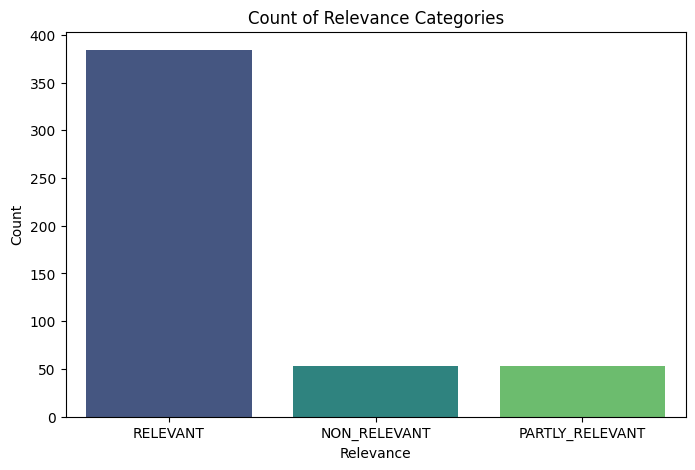

In [49]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_eval, x='relevance', palette='viridis')
plt.title('Count of Relevance Categories')
plt.xlabel('Relevance')
plt.ylabel('Count')
plt.show()

In [50]:
relevant_answers = df_eval[df_eval['relevance']=='RELEVANT']
relevant_answers[['question', 'answer', 'explanation']]

,question,answer,explanation
0,How do mental conditions affect daily life and...,Mental conditions can significantly impact dai...,The generated answer directly addresses the qu...
1,What is the range of severity for mental illne...,The range of severity for mental illnesses typ...,The generated answer directly addresses the qu...
2,What serious disorders require hospital care?,"Based on the context provided, serious disorde...",The generated answer directly addresses the qu...
3,How are mental illnesses similar to physical h...,Mental illnesses and physical health condition...,The generated answer effectively addresses the...
4,What treatments are effective for managing men...,The context provided does not include specific...,The generated answer provides several commonly...
...,...,...,...
477,Why is it important to discuss drugs with youn...,Discussing drugs with young people as they app...,The generated answer directly addresses the im...
479,How can I support my child in developing criti...,To support your child in developing critical t...,The generated answer provides a comprehensive ...
482,Is CBD oil safe to use with other medications?,The context provided does not contain specific...,The generated answer directly addresses the qu...
488,What should I be aware of regarding the nicoti...,"Unfortunately, the context does not provide an...",The generated answer provides pertinent inform...


In [51]:
non_relevant_answers = df_eval[df_eval['relevance']=='NON_RELEVANT']
non_relevant_answers[['question', 'answer', 'explanation']]

,question,answer,explanation
5,How many adults in America are affected by men...,The context provided does not include specific...,The generated answer does not address the ques...
6,Can you explain how mental illness impacts dif...,The provided context does not include any spec...,The generated answer does not address the ques...
7,What age groups are particularly vulnerable to...,The context provided does not contain any spec...,The generated answer does not address the ques...
33,Are there specific directories for local menta...,The provided context does not contain any info...,The generated answer does not provide any info...
39,Can you explain how different treatments can v...,"I'm sorry, but it seems that the provided cont...",The generated answer does not address the ques...
92,Are there specific qualifications I should loo...,The context does not provide specific qualific...,The generated answer states that it cannot pro...
98,What is the role of family members in these su...,The context provided does not contain any spec...,The generated answer states that there is no s...
109,Can you recommend any websites or hotlines for...,"I'm sorry, but the provided context does not c...",The generated answer does not provide any reco...
131,How can I build my resilience effectively?,"I'm sorry, but there is no context provided to...",The generated answer does not provide any info...
141,Can you explain the biological reasons for men...,The context provided does not include any spec...,The generated answer states that it cannot pro...


In [52]:
partly_relevant_answers = df_eval[df_eval['relevance']=='PARTLY_RELEVANT']
partly_relevant_answers[['question', 'answer', 'explanation']]

,question,answer,explanation
10,How common is mental illness among adults in A...,The context provided does not contain specific...,The generated answer acknowledges the lack of ...
16,What specific symptoms should I look out for i...,"I'm sorry, but it appears that there is no spe...",The generated answer acknowledges the question...
40,What should I expect during the treatment proc...,"I apologize, but it seems there was an error a...",The generated answer acknowledges the question...
43,What additional tests might I need for my diag...,"I'm sorry, but there is no context provided fo...",The response indicates a need for more context...
48,Are there specific areas of expertise among pr...,The context provided does not contain any info...,The generated answer acknowledges the lack of ...
55,What are the causes of this illness I am facing?,"I'm sorry, but it seems that the context you p...",The generated answer acknowledges the need for...
56,Are there other conditions that exhibit simila...,"Based on the provided context, there were no s...",The generated answer acknowledges the lack of ...
57,What tests do you recommend before starting tr...,"I'm sorry, but the provided context does not c...",The generated answer acknowledges the lack of ...
62,What kind of support can I expect from family ...,"I'm sorry, but there seems to be a lack of spe...",The generated answer acknowledges the need for...
63,Are there services available specifically in N...,"Based on the provided context, there is no spe...",The generated answer acknowledges the question...


In [53]:
df_eval.to_csv('../mentalhealthqa/data/rag-eval-gpt4o-mini.csv', index=False)

In [54]:
results = index.search(query="Can you recommend any websites or hotlines for mental health resources?", num_results=5)
for r in results:
    print(r['question_id'], '-', r['questions'][:80])

1667863 - Can you prevent mental health problems?
2176317 - How can I pay for mental health care?
1833460 - Where can older adults find help for mental health concerns?
7995219 - What's the difference between mental health and mental illness?
1030153 - How can I find a mental health professional for myself or my child?


In [55]:
non_relevant = df_eval[df_eval['relevance'] == 'NON_RELEVANT']

for _, row in non_relevant.iterrows():
    results = index.search(query=row['question'], num_results=10)
    retrieved_ids = [r['question_id'] for r in results]
    correct_id = row['id']
    
    if correct_id not in retrieved_ids:
        print(f"TRUE COVERAGE GAP -- correct doc not even in top 10")
        print("Q:", row['question'])
        print("Missing doc id:", correct_id)
        print()

TRUE COVERAGE GAP -- correct doc not even in top 10
Q: What age groups are particularly vulnerable to mental health issues?
Missing doc id: 2110618

TRUE COVERAGE GAP -- correct doc not even in top 10
Q: Are there specific directories for local mental health services?
Missing doc id: 1030153

TRUE COVERAGE GAP -- correct doc not even in top 10
Q: Can you explain how different treatments can vary in their impact?
Missing doc id: 8022026

TRUE COVERAGE GAP -- correct doc not even in top 10
Q: Can you recommend any websites or hotlines for mental health resources?
Missing doc id: 4031860

TRUE COVERAGE GAP -- correct doc not even in top 10
Q: How can I build my resilience effectively?
Missing doc id: 1667863

TRUE COVERAGE GAP -- correct doc not even in top 10
Q: Are there options for self-referring to a mental health program?
Missing doc id: 2612846

TRUE COVERAGE GAP -- correct doc not even in top 10
Q: Where can Indigenous individuals find specific counselling services?
Missing doc id:

In [62]:
evaluations_gpt4o=[]
for record in tqdm(ground_truth):
    doc_id=record['id']
    if id in evaluations:
        continue
    question=record['question']
    llm_answer=rag(question)
    prompt=template_2.format(question=question, answer_llm=llm_answer)
    evaluation=llm(prompt, model='gpt-4o')
    eval= json.loads(evaluation)
    evaluations_gpt4o.append((record, llm_answer, eval))

  0%|          | 0/490 [00:00<?, ?it/s]

In [63]:
df_eval = pd.DataFrame(evaluations_gpt4o, columns=['record', 'answer', 'evaluation'])

df_eval['id'] = df_eval.record.apply(lambda d: d['id'])
df_eval['question'] = df_eval.record.apply(lambda d: d['question'])
df_eval['relevance'] = df_eval.evaluation.apply(lambda d: d['Relevance'])
df_eval['explanation'] = df_eval.evaluation.apply(lambda d: d['Explanation'])

del df_eval['record']
del df_eval['evaluation']

In [66]:
df_eval.relevance.value_counts()

relevance
RELEVANT           377
NON_RELEVANT        62
PARTLY_RELEVANT     51
Name: count, dtype: int64

In [68]:
df_eval.to_csv('../mentalhealthqa/data/rag-eval-gpt-4o.csv', index=False)

C:\Users\HP\AppData\Local\Temp\ipykernel_26136\620821810.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eval, x='relevance', palette='viridis')


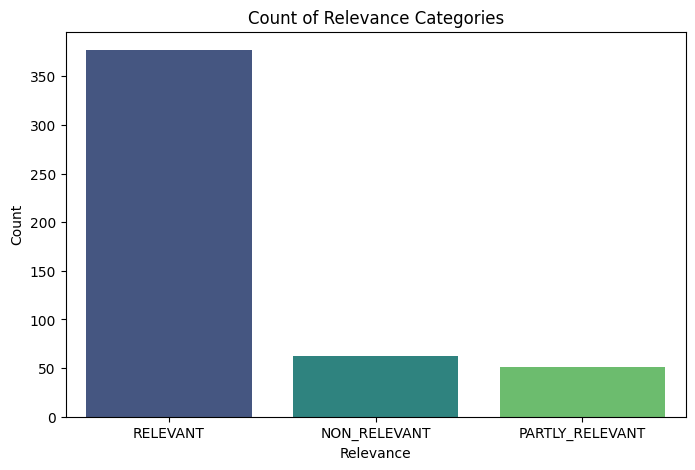

In [69]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_eval, x='relevance', palette='viridis')
plt.title('Count of Relevance Categories')
plt.xlabel('Relevance')
plt.ylabel('Count')
plt.show()